In [313]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import sys
import io
import datetime
import timeit
import os

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 100)
#pd.set_option("display.precision", 2)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print('Python version ' + sys.version)
print('Pandas version ' + pd.__version__)
print('NumPy version ' + np.__version__)
print('matplotlib version ' + matplotlib.__version__)

timestamp = datetime.datetime.now().strftime('%Y-%m%d-%H%M')
print("Timestamp:", timestamp)
tstart = timeit.default_timer()

Python version 3.12.4 (v3.12.4:8e8a4baf65, Jun  6 2024, 17:33:18) [Clang 13.0.0 (clang-1300.0.29.30)]
Pandas version 3.0.5
NumPy version 2.5.2
matplotlib version 3.11.1
Timestamp: 2026-0926-1656


In [314]:
dir_path = "data/"
file_names = ["alumni.csv", "course_catalog.csv", "employment_history.csv", "student_experience.csv", "students_current.csv", "transcripts.csv"]

dfs = []
for file_name in file_names:
    dfs.append(pd.read_csv(os.path.join(dir_path, file_name)))

df_alum, df_catalog, df_employ, df_studexp, df_studcurr, df_trans = dfs

In [315]:
for df in dfs:
    print(f"{df.info()}")

<class 'pandas.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 29 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   campus_id                           3200 non-null   str    
 1   major                               3200 non-null   str    
 2   degree_level                        3200 non-null   str    
 3   track                               3200 non-null   str    
 4   graduation_term                     3200 non-null   str    
 5   graduation_year                     3200 non-null   int64  
 6   entry_type                          3200 non-null   str    
 7   time_to_degree_years                3200 non-null   float64
 8   total_credits_earned                3200 non-null   int64  
 9   final_gpa                           3200 non-null   float64
 10  major_gpa                           3200 non-null   float64
 11  residency                           3200 non-null   st

In [316]:
df_bigcurr = df_trans.merge(df_studcurr, on="campus_id", how="inner")
df_bigalum = df_trans.merge(df_alum, on="campus_id", how="inner")
col = ["first_job_annual_salary_usd", "months_to_first_job", "first_job_is_remote"]
pd.to_numeric(col, errors="coerce")

col = ["first_job_annual_salary_usd", "months_to_first_job", "first_job_is_remote"]
pd.to_numeric(col, errors="coerce")

array([nan, nan, nan])

In [317]:
print(f"Current Student Major Count: {df_studcurr['major'].value_counts()}\n")
print(f"Alumni Major Count: {df_alum['major'].value_counts()}\n")

Current Student Major Count: major
Computer Science       1105
Information Systems     695
Name: count, dtype: int64

Alumni Major Count: major
Computer Science       1982
Information Systems    1218
Name: count, dtype: int64



## What is our definition of the "success" of a student?

"Success" means something different to different people depending on their career and educational goals. We are measuring how different factors are correlated to different metrics of success.

### Majors and their effect on "Success"

In [318]:
df_alumcareer = df_employ.merge(df_alum, on='campus_id', how='inner') # joining employ with alum table on campus_id: shows the career path of alum

aggregations = {'max_salary' : ('annual_salary_usd', 'max'), 
                'avg_salary' : ('annual_salary_usd', 'mean'),
                'job_count' : ('job_id', 'count')}

aggregations2 = {'job_count_avg': ('job_count', 'mean'),
                 'avg_salary': ('avg_salary', 'mean'),
                 'max_salary': ('max_salary', 'max'),
                 'alum_count': ('campus_id', 'count')}

df_alumcareerinfo = df_alumcareer.groupby(['campus_id', 'major', 'degree_level']).agg(**aggregations).reset_index().sort_values('avg_salary', ascending=False)
df_majorcareerinfo = df_alumcareerinfo.groupby(['major', 'degree_level']).agg(**aggregations2).reset_index()
df_majorcareerinfo

,major,degree_level,job_count_avg,avg_salary,max_salary,alum_count
0,Computer Science,Bachelor of Science,2.88,87580.55,205500,1252
1,Computer Science,Master of Science,2.86,90547.98,157000,69
2,Information Systems,Bachelor of Science,2.70,85849.91,220500,780
3,Information Systems,Master of Science,2.48,82232.96,165500,46


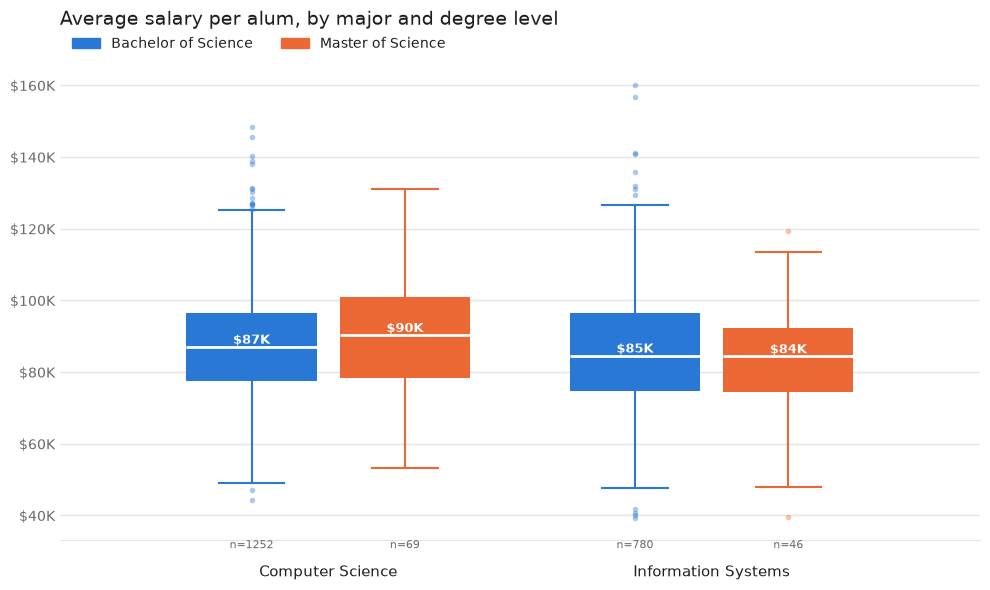

In [319]:
from matplotlib.ticker import FuncFormatter

SERIES_COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']  # colorblind-safe, fixed order
INK, INK_MUTED, GRID = '#1f1f1e', '#6b6a64', '#e6e5df'

majors  = sorted(df_alumcareerinfo['major'].unique())
degrees = sorted(df_alumcareerinfo['degree_level'].unique())
colors  = dict(zip(degrees, SERIES_COLORS))

fig, ax = plt.subplots(figsize=(10, 6))
width = 0.8 / len(degrees)

for i, degree in enumerate(degrees):
    # offset each degree's box within its major group
    positions = [m + (i - (len(degrees) - 1) / 2) * width for m in range(len(majors))]
    data = [df_alumcareerinfo.loc[(df_alumcareerinfo['major'] == m) &
                                  (df_alumcareerinfo['degree_level'] == degree), 'avg_salary']
            for m in majors]
    bp = ax.boxplot(data, positions=positions, widths=width * 0.85, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2),
                    boxprops=dict(linewidth=0),
                    whiskerprops=dict(color=colors[degree], linewidth=1.5),
                    capprops=dict(color=colors[degree], linewidth=1.5),
                    flierprops=dict(marker='o', markersize=4, alpha=0.4,
                                    markerfacecolor=colors[degree], markeredgecolor='none'))
    for box in bp['boxes']:
        box.set_facecolor(colors[degree])

    # label the median and sample size for each box
    for pos, d in zip(positions, data):
        if len(d):
            ax.text(pos, d.median(), f"${d.median()/1000:.0f}K", ha='center', va='bottom',
                    fontsize=9, color='white', fontweight='bold')
        ax.text(pos, 0, f"n={len(d)}", ha='center', va='top', fontsize=8, color=INK_MUTED,
                transform=ax.get_xaxis_transform())

ax.set_xticks(range(len(majors)), majors, fontsize=11, color=INK)
ax.tick_params(axis='x', length=0, pad=18)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v/1000:.0f}K"))
ax.tick_params(axis='y', colors=INK_MUTED, length=0)
ax.grid(axis='y', color=GRID, linewidth=1)
ax.set_axisbelow(True)
for side in ['top', 'right', 'left']:
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color(GRID)

ax.set_title('Average salary per alum, by major and degree level', loc='left',
             fontsize=14, color=INK, pad=28)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=colors[d]) for d in degrees],
          labels=degrees, loc='lower left', bbox_to_anchor=(0, 1.0), ncol=len(degrees),
          frameon=False, fontsize=10, labelcolor=INK)

plt.tight_layout()
plt.show()


Most alumni in the dataset only hold a bachelor's degree (2,032 vs 115 with a master's), so the master's comparisons are built on small samples. Among the alumni, the typical salary gap between COmputer Science and Information Systems is small: CS alumni earn a median of about 3% more, and the two distributions overlap almost entirely. Although Information Systems is often viewed as the weaker major, the data shows that both lead to very similar salries.

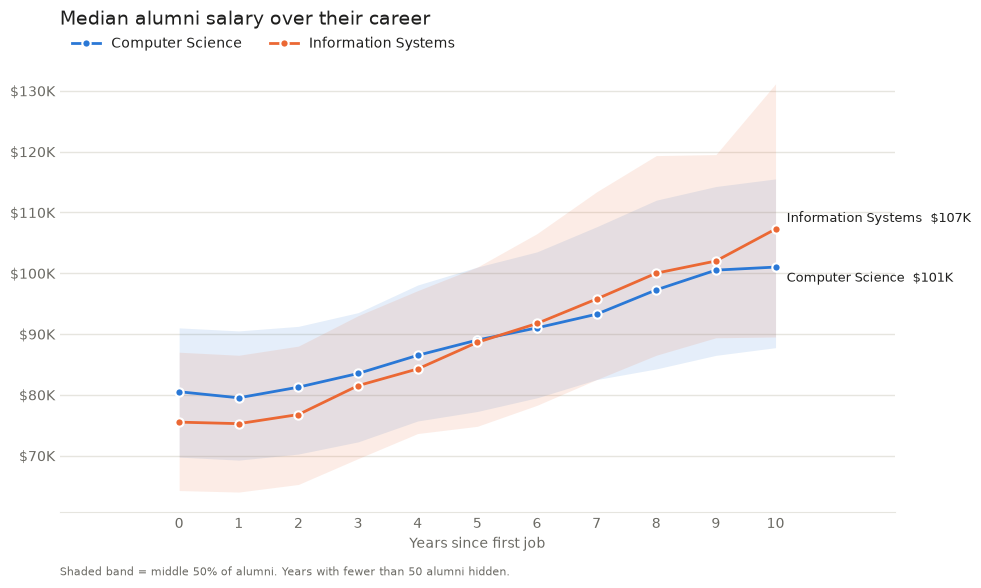

In [320]:
MIN_N = 50   # hide years with too few alumni to trust the median

# salary each alum was earning at each full year since their first job started
career = df_alumcareer.copy()
career['start_date'] = pd.to_datetime(career['start_date'])
career['end_date'] = pd.to_datetime(career['end_date']).fillna(pd.Timestamp.today())  # current jobs
first_start = career.groupby('campus_id')['start_date'].transform('min')
career['start_yr'] = (career['start_date'] - first_start).dt.days / 365.25
career['end_yr'] = (career['end_date'] - first_start).dt.days / 365.25

rows = []
for (cid, major), jobs in career.sort_values('start_date').groupby(['campus_id', 'major']):
    for year in range(int(jobs['end_yr'].max()) + 1):
        held = jobs[jobs['start_yr'] <= year]            # jobs started by this point
        rows.append((cid, major, year, held['annual_salary_usd'].iloc[-1]))
by_alum_year = pd.DataFrame(rows, columns=['campus_id', 'major', 'years_in', 'annual_salary_usd'])

trend = (by_alum_year.groupby(['major', 'years_in'])['annual_salary_usd']
                     .agg(median='median', p25=lambda s: s.quantile(.25),
                          p75=lambda s: s.quantile(.75), n='count')
                     .reset_index())
trend = trend[trend['n'] >= MIN_N]

majors = sorted(trend['major'].unique())
colors = dict(zip(majors, SERIES_COLORS))

fig, ax = plt.subplots(figsize=(10, 6))
for major in majors:
    t = trend[trend['major'] == major]
    ax.fill_between(t['years_in'], t['p25'], t['p75'], color=colors[major], alpha=0.12, linewidth=0)
    ax.plot(t['years_in'], t['median'], color=colors[major], linewidth=2,
            marker='o', markersize=6, markeredgecolor='white', markeredgewidth=1.5, label=major)

# direct-label each line's end; nudge labels apart so they don't collide
ends = trend.loc[trend.groupby('major')['years_in'].idxmax()].sort_values('median')
for i, (_, row) in enumerate(ends.iterrows()):
    ax.annotate(f"{row['major']}  ${row['median']/1000:.0f}K", (row['years_in'], row['median']),
                xytext=(8, (i - (len(ends) - 1) / 2) * 16), textcoords='offset points',
                va='center', fontsize=9, color=INK)

ax.set_xlabel('Years since first job', color=INK_MUTED)
ax.set_xticks(sorted(trend['years_in'].unique()))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v/1000:.0f}K"))
ax.tick_params(colors=INK_MUTED, length=0)
ax.grid(axis='y', color=GRID, linewidth=1)
ax.set_axisbelow(True)
for side in ['top', 'right', 'left']:
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.margins(x=0.2)

ax.set_title('Median alumni salary over their career', loc='left', fontsize=14, color=INK, pad=28)
ax.legend(loc='lower left', bbox_to_anchor=(0, 1.0), ncol=len(majors), frameon=False,
          fontsize=10, labelcolor=INK)
ax.text(0, -0.14, f"Shaded band = middle 50% of alumni. Years with fewer than {MIN_N} alumni hidden.",
        transform=ax.transAxes, fontsize=8, color=INK_MUTED)

plt.tight_layout()
plt.show()


This idea of similar salaries is further shown in the above chart, where the median salary of alumni is plotted over time and compared to each other. This chart shows that IS majors close an observed initial gap by around the 5 year mark, and since there are less alumni in later years beyond the 8 year mark, the gap at the end of the chart gives a less certain conclusion of the IS major lead in salary, especially since the minimum alumni for a year is 50 (as set by me).

In [321]:
df_corr = df_alum.copy()
df_corr['first_job_annual_salary_usd'] = pd.to_numeric(df_corr['first_job_annual_salary_usd'], errors='coerce')
df_corr = df_corr.dropna(subset=['first_job_annual_salary_usd'])
df_corr['is_info_systems'] = (df_corr['major'] == 'Information Systems').astype(int)

df_corr['is_info_systems'].corr(df_corr['first_job_annual_salary_usd'])

np.float64(-0.13530589801718018)

A correlation coefficient of ~-0.135 (IS coded as 1) tells us that major and salary are WEAKLY correlated since it's closer to 0, but not negligible. Squaring it to get 0.018 shows that only about 2% of the variation in starting salary is explained by the major. The negative value refers to the fact that IS alumni start slightly lower on average, but the two distributions overlap almost entirely.

### Internships and their effect on "Success"

In [322]:
df_intern = df_alum.copy()
for c in ['first_job_annual_salary_usd', 'months_to_first_job']:
    df_intern[c] = pd.to_numeric(df_intern[c], errors='coerce')   # 'Not Applicable' -> NaN
df_intern['employed_full_time'] = df_intern['first_destination'] == 'Employed Full-Time'
df_intern['return_offer'] = df_intern['first_job_found_via'] == 'Return Offer from Internship'

by_intern = (df_intern.groupby('internship_count')
             .agg(alum_count=('campus_id', 'count'),
                  median_salary=('first_job_annual_salary_usd', 'median'),
                  median_months=('months_to_first_job', 'median'),
                  pct_full_time=('employed_full_time', 'mean'),
                  pct_return_offer=('return_offer', 'mean'))
             .reset_index())
by_intern


,internship_count,alum_count,median_salary,median_months,pct_full_time,pct_return_offer
0,0,773,67750.00,4.20,0.58,0.00
1,1,1368,78750.00,0.90,0.62,0.17
2,2,837,83750.00,0.30,0.68,0.34
3,3,212,87500.00,0.30,0.65,0.47
4,4,10,70500.00,0.25,0.60,0.40


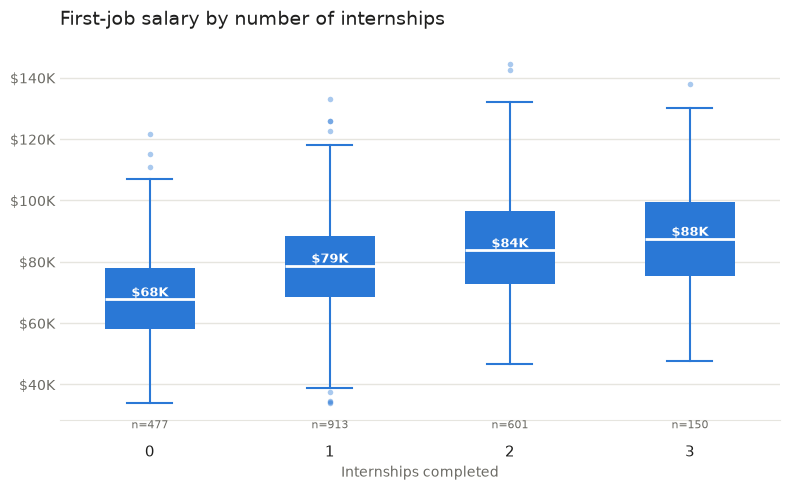

In [323]:
counts = [c for c in sorted(df_intern['internship_count'].unique())
          if (df_intern['internship_count'] == c).sum() >= MIN_N]
data = [df_intern.loc[df_intern['internship_count'] == c, 'first_job_annual_salary_usd'].dropna() for c in counts]

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(data, positions=range(len(counts)), widths=0.5, patch_artist=True,
                medianprops=dict(color='white', linewidth=2), boxprops=dict(linewidth=0),
                whiskerprops=dict(color=SERIES_COLORS[0], linewidth=1.5),
                capprops=dict(color=SERIES_COLORS[0], linewidth=1.5),
                flierprops=dict(marker='o', markersize=4, alpha=0.4,
                                markerfacecolor=SERIES_COLORS[0], markeredgecolor='none'))
for box in bp['boxes']:
    box.set_facecolor(SERIES_COLORS[0])
for pos, d in enumerate(data):
    ax.text(pos, d.median(), f"${d.median()/1000:.0f}K", ha='center', va='bottom',
            fontsize=9, color='white', fontweight='bold')
    ax.text(pos, 0, f"n={len(d)}", ha='center', va='top', fontsize=8, color=INK_MUTED,
            transform=ax.get_xaxis_transform())

ax.set_xticks(range(len(counts)), counts, fontsize=11, color=INK)
ax.tick_params(axis='x', length=0, pad=18)
ax.set_xlabel('Internships completed', color=INK_MUTED)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v/1000:.0f}K"))
ax.tick_params(axis='y', colors=INK_MUTED, length=0)
ax.grid(axis='y', color=GRID, linewidth=1)
ax.set_axisbelow(True)
for side in ['top', 'right', 'left']:
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.set_title('First-job salary by number of internships', loc='left', fontsize=14, color=INK, pad=16)
plt.tight_layout()
plt.show()


The box chart suggests that there is a large difference between the starting salaries of alum who completed 0 internships and alum who completed 3 internships. However, there is a lot of overlap between the distributions of 2 internships and 3 internships, which suggests that the potential of a higher salary levels off at 2 and 3 internships.

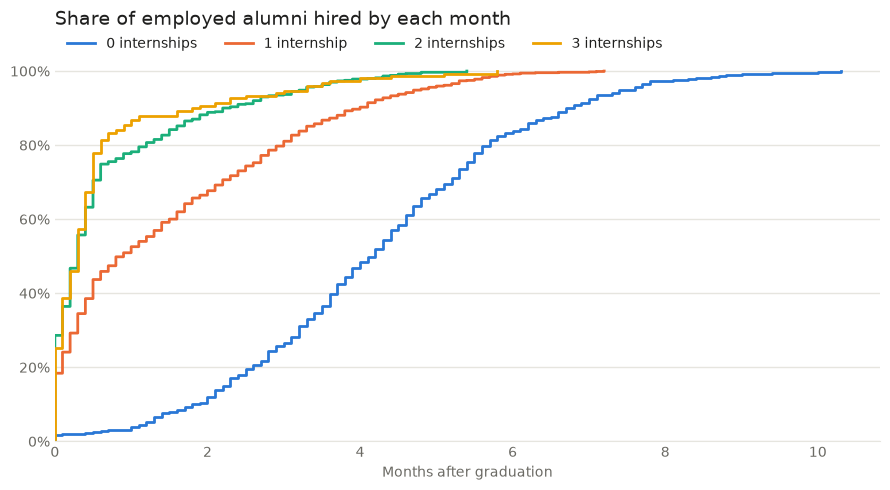

In [324]:
fig, ax = plt.subplots(figsize=(9, 5))
for i, c in enumerate(counts):
    months = np.sort(df_intern.loc[df_intern['internship_count'] == c, 'months_to_first_job'].dropna())
    pct_hired = np.arange(1, len(months) + 1) / len(months)
    ax.step(months, pct_hired, where='post', color=SERIES_COLORS[i], linewidth=2)

ax.set_xlabel('Months after graduation', color=INK_MUTED)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.tick_params(colors=INK_MUTED, length=0)
ax.grid(axis='y', color=GRID, linewidth=1)
ax.set_axisbelow(True)
for side in ['top', 'right', 'left']:
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.set_xlim(0, None)
ax.set_ylim(0, 1.02)
ax.set_title('Share of employed alumni hired by each month', loc='left', fontsize=14, color=INK, pad=28)
ax.legend([f"{c} internship{'s' if c != 1 else ''}" for c in counts], loc='lower left',
          bbox_to_anchor=(0, 1.0), ncol=len(counts), frameon=False, fontsize=10, labelcolor=INK)
plt.tight_layout()
plt.show()

The overlap in the salary chart is reflected in a similar pattern by the above chart that shows the hiring speed. Most employed alumni with 2 or 3 internships were hired within a month of graduation while those with 0 or 1 internships took a lot longer. This suggests that the 3rd internship is adding little value to both the salary and hire time as compared to a 2nd internship.

In [325]:
had_intern = df_intern[(df_intern['internship_count'] > 0) & df_intern['first_job_annual_salary_usd'].notna()]

offer_table = (had_intern.pivot_table(index='internship_count', columns='return_offer',
                                      values='first_job_annual_salary_usd', aggfunc=['median', 'count'])
               .rename(columns={False: 'no_offer', True: 'offer'}))
offer_table.columns = [f'{stat}_{grp}' for stat, grp in offer_table.columns]   # flatten the 2-level header
offer_table['offer_premium'] = offer_table['median_offer'] - offer_table['median_no_offer']
offer_table = offer_table[offer_table['count_offer'] >= 10].reset_index()   # 4 internships has only 4 offers
offer_table

,internship_count,median_no_offer,median_offer,count_no_offer,count_offer,offer_premium
0,1,77500.00,82750.00,682,231,5250.00
1,2,81000.00,87750.00,319,282,6750.00
2,3,83500.00,90250.00,51,99,6750.00
